In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [25]:
# Load dữ liệu
data = np.load("processed_data.npz")

# Reshape dữ liệu về dạng vector (phẳng) cho Naive Bayes
# (N_samples, 28, 28) -> (N_samples, 784)
X_train = data['x_train'].reshape(-1, 784)
X_val = data['x_val'].reshape(-1, 784)
X_test = data['x_test'].reshape(-1, 784)

y_train = data['y_train']
y_val = data['y_val']
y_test = data['y_test']

print(f"Train shape: {X_train.shape}") 
print(f"Val shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (50000, 784)
Val shape: (10000, 784)
Test shape: (10000, 784)


In [ ]:
class BernoulliNB_General:
    def __init__(self, binarize_threshold=0.5, alpha=1.0):
        self.threshold = binarize_threshold
        self.alpha = alpha
        self.feature_probs = None # P(xi=1|c)
        self.priors = None        # P(c)
        self.classes = None

    def fit(self, X, y):
        # 1. Binarize dữ liệu dựa trên threshold
        X_bin = (X > self.threshold).astype(int)
        
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        
        self.feature_probs = np.zeros((len(self.classes), n_features))
        self.priors = np.zeros(len(self.classes))
        
        for idx, c in enumerate(self.classes):
            X_c = X_bin[y == c]
            N_c = X_c.shape[0] # Số lượng mẫu của lớp c
            
            # Tính P(c)
            self.priors[idx] = N_c / float(n_samples)
            
            # Đếm số lần pixel xuất hiện
            count = X_c.sum(axis=0)
            
            # Tính Likelihood P(xi=1|c) với ct tổng quát có Alpha
            # P = (count + alpha) / (N_c + 2*alpha)
            # (Mẫu số cộng 2*alpha vì biến nhị phân có 2 trạng thái 0 và 1)
            self.feature_probs[idx] = (count + self.alpha) / (N_c + 2 * self.alpha)

    def predict(self, X):
        X_bin = (X > self.threshold).astype(int)
        log_probs = np.zeros((len(X), len(self.classes)))
        
        for idx, c in enumerate(self.classes):
            log_prior = np.log(self.priors[idx])
            p = self.feature_probs[idx]
            
            # Tính Log Likelihood an toàn (tránh log(0))
            # log(P(x|c)) = sum(x*log(p) + (1-x)*log(1-p))
            epsilon = 1e-9 # Phòng hờ trường hợp alpha=0 
            p = np.clip(p, epsilon, 1 - epsilon)
            
            log_likelihood = np.sum(X_bin * np.log(p) + (1 - X_bin) * np.log(1 - p), axis=1)
            
            log_probs[:, idx] = log_prior + log_likelihood
            
        return self.classes[np.argmax(log_probs, axis=1)]

In [27]:
# Chạy với công thức học trên lớp (các chỉ số cố định chưa tinh chỉnh) với Alpha là 1 và ngưỡng là 0.5
bnb_model = BernoulliNB_General(binarize_threshold=0.5, alpha=1.0)
bnb_model.fit(X_train, y_train)

# Đánh giác accuracy trên tập train, val, test
train_acc = np.mean(bnb_model.predict(X_train) == y_train)
val_acc = np.mean(bnb_model.predict(X_val) == y_val)
test_acc = np.mean(bnb_model.predict(X_test) == y_test)

print("Kết quả trước tinh chỉnh tham số")
print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Val Accuracy: {val_acc*100:.2f}%")
print(f"Test Accuracy: {test_acc*100:.2f}%")

Kết quả trước tinh chỉnh tham số
Train Accuracy: 83.65%
Val Accuracy: 83.09%
Test Accuracy: 84.27%


Threshold: 0.1 - Alpha: 1.0    | 83.21%
Threshold: 0.1 - Alpha: 0.5    | 83.24%
Threshold: 0.1 - Alpha: 0.1    | 83.27%
Threshold: 0.1 - Alpha: 0.01   | 83.28%
Threshold: 0.1 - Alpha: 0.001  | 83.29%
Threshold: 0.1 - Alpha: 0.0001 | 83.29%
Threshold: 0.2 - Alpha: 1.0    | 83.26%
Threshold: 0.2 - Alpha: 0.5    | 83.31%
Threshold: 0.2 - Alpha: 0.1    | 83.34%
Threshold: 0.2 - Alpha: 0.01   | 83.35%
Threshold: 0.2 - Alpha: 0.001  | 83.37%
Threshold: 0.2 - Alpha: 0.0001 | 83.36%
Threshold: 0.3 - Alpha: 1.0    | 83.22%
Threshold: 0.3 - Alpha: 0.5    | 83.25%
Threshold: 0.3 - Alpha: 0.1    | 83.30%
Threshold: 0.3 - Alpha: 0.01   | 83.35%
Threshold: 0.3 - Alpha: 0.001  | 83.37%
Threshold: 0.3 - Alpha: 0.0001 | 83.37%
Threshold: 0.4 - Alpha: 1.0    | 83.03%
Threshold: 0.4 - Alpha: 0.5    | 83.04%
Threshold: 0.4 - Alpha: 0.1    | 83.12%
Threshold: 0.4 - Alpha: 0.01   | 83.14%
Threshold: 0.4 - Alpha: 0.001  | 83.19%
Threshold: 0.4 - Alpha: 0.0001 | 83.18%
Threshold: 0.5 - Alpha: 1.0    | 83.09%


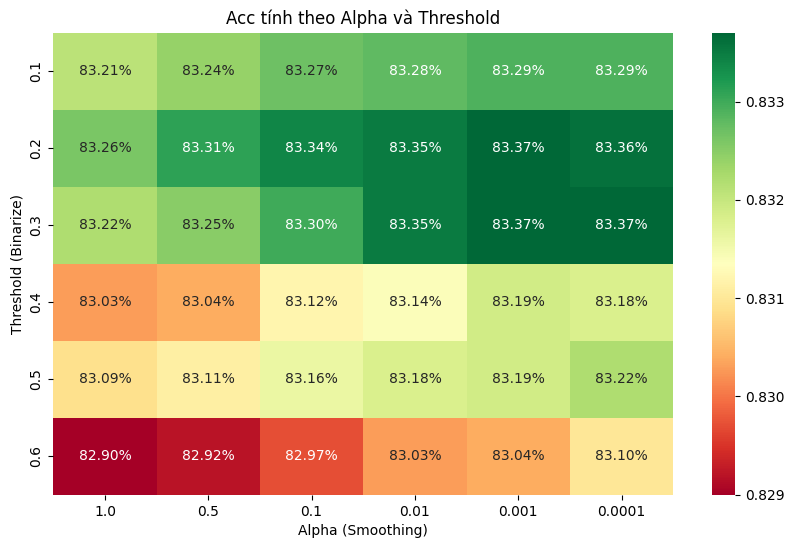

Chọn Threshold = 0.2, Alpha = 0.001


In [28]:
# tìm cặp thông số threshold, alpha tối ưu (dùng trên tập Validation trươc)
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
alphas = [1.0, 0.5, 0.1, 0.01, 0.001, 0.0001]

best_acc = 0
best_params = {}

# tạo ma trận cho heatmap
results_matrix = np.zeros((len(thresholds), len(alphas)))
for i, thresh in enumerate(thresholds):
    for j, alp in enumerate(alphas):
        # Train
        model = BernoulliNB_General(binarize_threshold=thresh, alpha=alp)
        model.fit(X_train, y_train)
        
        # Đánh giá trên tập Val
        acc = np.mean(model.predict(X_val) == y_val)
        results_matrix[i, j] = acc
        
        # Lưu kết quả tốt nhất để tí dùng bằng biến cho dễ
        if acc > best_acc:
            best_acc = acc
            best_params = {'threshold': thresh, 'alpha': alp}
            
        print(f"Threshold: {thresh} - Alpha: {alp:<6} | {acc*100:.2f}%")

# Vẽ heatmap kết quả
plt.figure(figsize=(10, 6))
sns.heatmap(results_matrix, annot=True, fmt=".2%",
            xticklabels=alphas, yticklabels=thresholds, cmap="RdYlGn")
plt.xlabel("Alpha (Smoothing)")
plt.ylabel("Threshold (Binarize)")
plt.title("Acc tính theo Alpha và Threshold")
plt.show()
print(f"Chọn Threshold = {best_params['threshold']}, Alpha = {best_params['alpha']}")

Chào bạn, đây là một câu hỏi rất sâu sắc về tư duy lựa chọn mô hình.

Câu trả lời ngắn gọn: **Không có vấn đề gì cả.** Việc máy tính chọn cặp `0.2 - 0.001` thay vì các cặp khác có độ chính xác tương đương hoàn toàn là do **cơ chế lập trình**, nhưng xét về mặt toán học, sự lựa chọn này (vô tình) lại là một lựa chọn **rất an toàn**.

Dưới đây là giải thích chi tiết tại sao lại như vậy:

### 1. Tại sao máy lại chọn 0.2 - 0.001? (Lý do Kỹ thuật)

Đây là lý do "ngây thơ" nhất: **Do thứ tự ưu tiên trong vòng lặp (First Come, First Served).**

Trong code của bạn:

```python
thresholds = [0.1, 0.2, 0.3, ...] # 0.2 đứng trước 0.3
if acc > best_acc: # Chỉ cập nhật khi LỚN HƠN HẲN
    best_acc = acc
    best_params = ...

```

1. Máy chạy đến `Threshold = 0.2`, tìm được `Alpha = 0.001`, độ chính xác đạt đỉnh (ví dụ 83.37%). Nó lưu lại kết quả này.
2. Sau đó máy chạy tiếp đến `Threshold = 0.3`, cũng tìm được độ chính xác 83.37% (bằng nhau).
3. Do `83.37 > 83.37` là **Sai (False)**, máy **không cập nhật** kết quả mới mà giữ nguyên kết quả cũ.

=> Vì thế, cặp nào xuất hiện trước trong danh sách `thresholds` sẽ được chọn.

---

### 2. Nếu bạn phải tự tay chọn, nên chọn cái nào? (Lý do Toán học)

Giả sử cả 3 cặp sau đều cho độ chính xác y hệt nhau:

* **A:** Threshold 0.2, Alpha 0.001 (Máy chọn)
* **B:** Threshold 0.3, Alpha 0.001
* **C:** Threshold 0.3, Alpha 0.0001

Nếu là một chuyên gia, tôi sẽ phân tích để "bẻ kèo" (tie-break) như sau:

#### Giữa Alpha 0.001 và 0.0001 (So sánh B và C)

* **Quy tắc:** Khi độ chính xác ngang nhau, hãy chọn **Alpha lớn hơn**.
* **Tại sao?** Alpha giúp làm mượt (smoothing) để tránh Overfitting (học vẹt).
* Alpha càng nhỏ (), mô hình càng tin vào dữ liệu huấn luyện một cách cực đoan.
* Alpha lớn hơn (), mô hình "khiêm tốn" hơn, chấp nhận xác suất sai số nhẹ.


* **Kết luận:** Cặp B (Alpha 0.001) tốt hơn C (Alpha 0.0001) vì nó ổn định hơn, ít rủi ro bị lỗi khi gặp dữ liệu lạ trong tương lai.

#### Giữa Threshold 0.2 và 0.3 (So sánh A và B)

* **Threshold 0.2:** "Dễ tính". Chỉ cần pixel hơi xám (20% độ đậm) là tính là mực.
* *Ưu điểm:* Bắt được các nét viết thanh mảnh, đứt đoạn (điều thường gặp ở số 5, số 8 viết nhanh).
* *Nhược điểm:* Dễ bắt nhầm bụi bẩn (noise) thành mực.


* **Threshold 0.3:** "Khắt khe hơn". Phải đậm hơn chút (30%) mới tính.
* *Ưu điểm:* Lọc nhiễu tốt, ảnh sạch.
* *Nhược điểm:* Có thể làm đứt nét các chữ số viết mờ.


* **Kết luận:** Với bộ dữ liệu chữ viết tay (MNIST), các nét mực thường quan trọng hơn nền. Thà bắt nhầm chút bụi còn hơn là bỏ sót nét làm số 8 biến thành số 0 (do mất nét giữa).
-> **Threshold 0.2 (thấp hơn) thường an toàn hơn để bảo toàn nét chữ.**

### Tổng kết

Việc máy tính chọn **0.2 - 0.001** (Cặp A) là do may mắn của thứ tự sắp xếp, nhưng nó trùng hợp lại là lựa chọn tốt nhất vì:

1. **Alpha 0.001** đủ an toàn (tốt hơn 0.0001).
2. **Threshold 0.2** bảo toàn nét chữ tốt (thường tốt hơn 0.3 đối với chữ viết tay mờ).

Vì vậy, bạn hoàn toàn yên tâm với kết quả này nhé! Nó không bị ảnh hưởng xấu gì đâu.

In [29]:
# Chạy mô hình với tham số đã tối ưu, rồi đánh giá trên Test
final_model = BernoulliNB_General(
    binarize_threshold=0.2, 
    alpha=0.001
)
final_model.fit(X_train, y_train)

# Đánh giá accuracy trên tập train, val, test
train_acc = np.mean(final_model.predict(X_train) == y_train)
val_acc = np.mean(final_model.predict(X_val) == y_val)
test_pred = final_model.predict(X_test) # Lưu biến này để vẽ heatmap sau
test_acc = np.mean(test_pred == y_test)

print("\n Kết quả sau tinh chỉnh tham số")
print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Val Accuracy: {val_acc*100:.2f}%")
print(f"Test Accuracy: {test_acc*100:.2f}%")


 Kết quả sau tinh chỉnh tham số
Train Accuracy: 83.65%
Val Accuracy: 83.37%
Test Accuracy: 84.62%


In [30]:
# Coi kết quả từng số đucợ đánh giá trên tập Test
def evaluate_per_class(y_true, y_pred):
    classes = np.unique(y_true)
    for c in classes:
        idx = (y_true == c)
        preds_c = y_pred[idx]
        correct = np.sum(preds_c == c)
        total = len(preds_c)
        acc = correct / total if total > 0 else 0
        print(f"Số {c} | {acc*100:.2f}% | {correct}/{total}")
evaluate_per_class(y_test, test_pred)

Số 0 | 90.71% | 889/980
Số 1 | 95.24% | 1081/1135
Số 2 | 82.75% | 854/1032
Số 3 | 83.86% | 847/1010
Số 4 | 81.36% | 799/982
Số 5 | 71.97% | 642/892
Số 6 | 90.29% | 865/958
Số 7 | 84.34% | 867/1028
Số 8 | 78.95% | 769/974
Số 9 | 84.14% | 849/1009


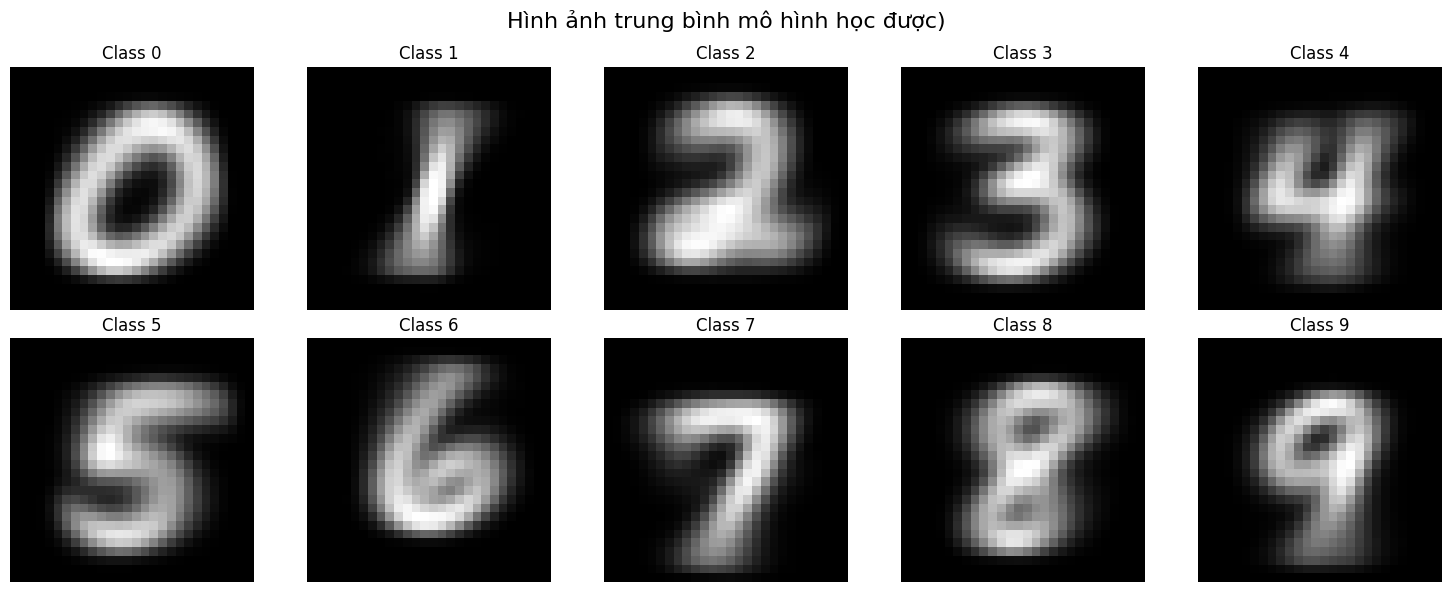

In [31]:
plt.figure(figsize=(15, 6))
plt.suptitle("Hình ảnh trung bình mô hình học được)", fontsize=16)

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(final_model.feature_probs[i].reshape(28, 28), cmap='gray')
    plt.title(f"Class {i}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [32]:
def confusion_matrix(y_true, y_pred, n_classes=10):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for true, pred in zip(y_true, y_pred):
        cm[true, pred] += 1
    return cm

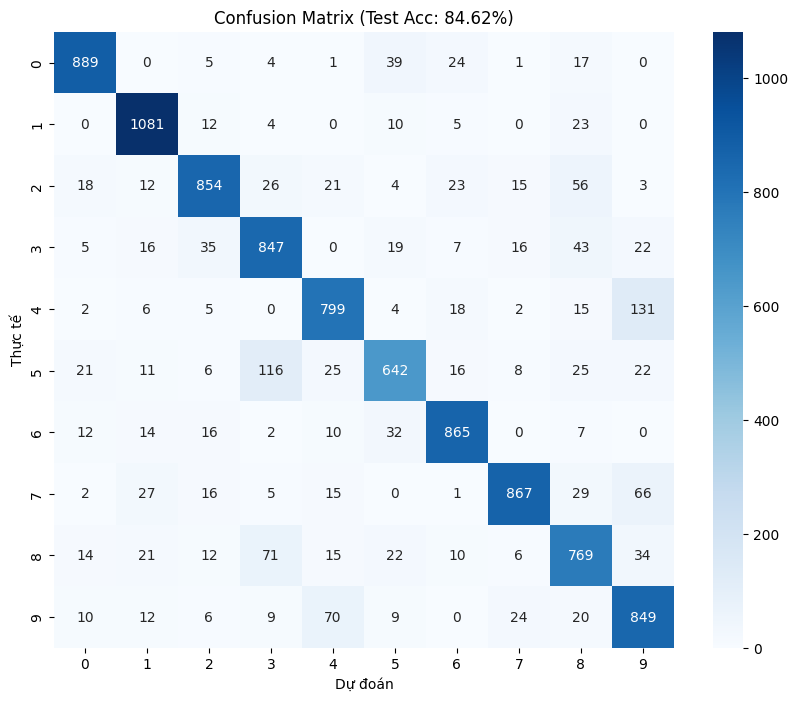

In [33]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix (Test Acc: {test_acc*100:.2f}%)")
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.show()

In [34]:
# f1-score (macro) từ cm
cm = confusion_matrix(y_test, test_pred)
num_classes = cm.shape[0]

precision_list, recall_list, f1_list = [], [], []

for i in range(num_classes):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)
print("Macro Metrics avg:")
print(f"Macro Precision: {sum(precision_list)/num_classes:.4f}")
print(f"Macro Recall: {sum(recall_list)/num_classes:.4f}")
print(f"Macro F1-score: {sum(f1_list)/num_classes:.4f}")


Macro Metrics avg:
Macro Precision: 0.8472
Macro Recall: 0.8436
Macro F1-score: 0.8444


In [35]:
with open("naive_bayes_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

print("Đã lưu naive_bayes_model.pkl")

Đã lưu naive_bayes_model.pkl
